# Understand Handling Outliers,Encoding Techniques and scalling methods

In [4]:
# import libraries 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load dataset 
data=pd.read_csv("insurance.csv")

In [6]:
# Some basic checks
# print first 5 rows
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
# print last 5 rows
data.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [7]:
# check number of rows and columns
data.shape

(1338, 7)

In [8]:
# check info: memory usage  dtype etc
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
# find statistical report 
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
# print categorical columns
cat_col=data.select_dtypes(include="object")
cat_col

,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest
...,...,...,...
1333,male,no,northwest
1334,female,no,northeast
1335,female,no,southeast
1336,female,no,southwest


In [12]:
# print numerical columns
num_col=data.select_dtypes(include=["int64","float64"])
num_col

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520
...,...,...,...,...
1333,50,30.970,3,10600.54830
1334,18,31.920,0,2205.98080
1335,18,36.850,0,1629.83350
1336,21,25.800,0,2007.94500


In [15]:
data.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [16]:
# unique cat col
for x in cat_col:
    print(x,"---->",data[x].unique())

sex ----> ['female' 'male']
smoker ----> ['yes' 'no']
region ----> ['southwest' 'southeast' 'northwest' 'northeast']


In [17]:
# cat col value count
for x in num_col:
    print(data[x].value_counts())

age
18    69
19    68
50    29
51    29
47    29
46    29
45    29
20    29
48    29
52    29
22    28
49    28
54    28
53    28
21    28
26    28
24    28
25    28
28    28
27    28
23    28
43    27
29    27
30    27
41    27
42    27
44    27
31    27
40    27
32    26
33    26
56    26
34    26
55    26
57    26
37    25
59    25
58    25
36    25
38    25
35    25
39    25
61    23
60    23
63    23
62    23
64    22
Name: count, dtype: int64
bmi
32.300    13
28.310     9
30.495     8
30.875     8
31.350     8
          ..
46.200     1
23.800     1
44.770     1
32.120     1
30.970     1
Name: count, Length: 548, dtype: int64
children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64
charges
1639.56310     2
16884.92400    1
29330.98315    1
2221.56445     1
19798.05455    1
              ..
7345.08400     1
26109.32905    1
28287.89766    1
1149.39590     1
29141.36030    1
Name: count, Length: 1337, dtype: int64


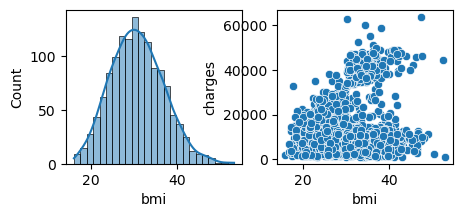

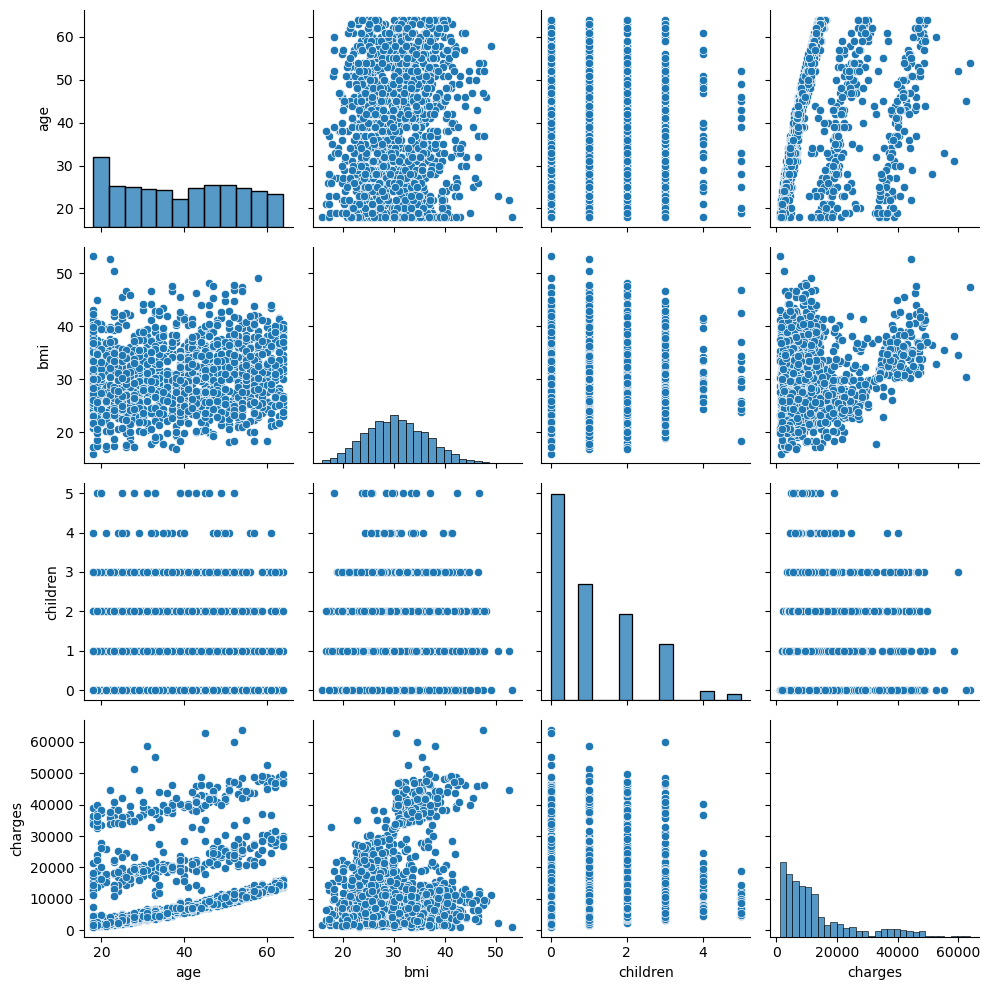

In [28]:
# Exploratory data analysis
fig,ax=plt.subplots(1,2,figsize=(5,2))
# univariate---histplot,boxplot,countplot
sns.histplot(data=data,x="bmi",ax=ax[0],kde=True)
# Bivariate ---scatterplot,bar plot,line chart
sns.scatterplot(data=data,x="bmi",y="charges",ax=ax[1])
# multivariate ------heatmap,pairplot
sns.pairplot(data)
plt.tight_layout()


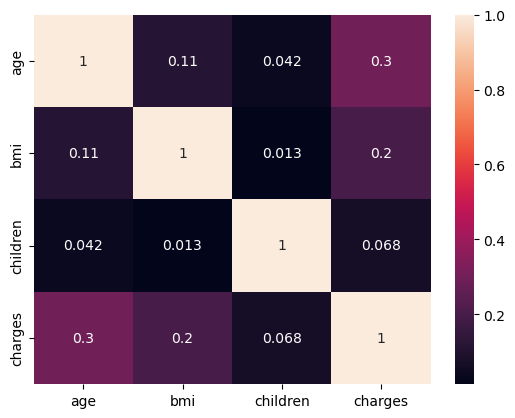

In [29]:
sns.heatmap(num_col.corr(),annot=True)
plt.show()

# Handle outliers

outliers are data points which are extremly different from rest of others.

Eg: Age of students : [20,21,22,23,24,98,100]

In this 98 and 100 are outliers.

## How to identify Outliers using
##### Boxplot
##### Scatterplot
##### histogram

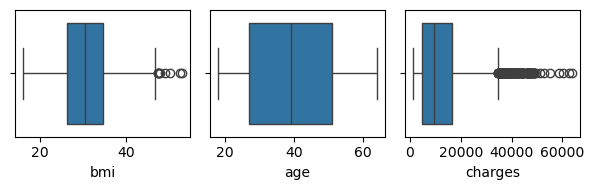

In [31]:
fig,ax=plt.subplots(1,3,figsize=(6,2))
sns.boxplot(data,x="bmi",ax=ax[0])
sns.boxplot(data,x="age",ax=ax[1])
sns.boxplot(data,x="charges",ax=ax[2])
plt.tight_layout()
# There are outliers in bmi and charges towards right side.

# Find Outliers

## IQR(Inter quartile range): Used when data distribution is skewed.
## 3-sigma rule : Used when data is normal
## Outliers should handled only if % of outliers are less than 5%.

#### check distribution of bmi and charges also skewness

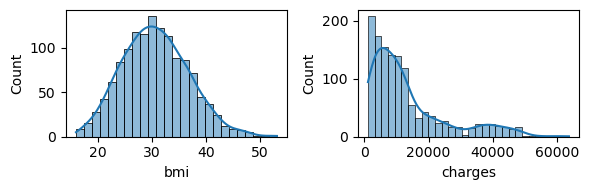

In [33]:
fig,ax=plt.subplots(1,2,figsize=(6,2))
sns.histplot(data,x="bmi",ax=ax[0],kde=True)
sns.histplot(data,x="charges",ax=ax[1],kde=True)
plt.tight_layout()

#### looking at image it look like bmi normal distribution and charges right skewed still check numeric value of skew

In [35]:
# check skewness for bmi
data.loc[:,"bmi"].skew()


0.2840471105987448

#### since value in between range -0.5 to 0.5 so it is normal distribution we can apply 3 -sigma rule method on bmi

In [36]:
# check skewness for charges
data.loc[:,"charges"].skew()

1.5158796580240388

#### since skew is >0.5 so it right skewed we can apply IQR before that check for % is it <5% or not

# IQR method for charges
Data distribution is skewed

1. Find Q1
2. FInd Q3
3. IQR
4. lower_limit = Q1-1.5*IQR
5. upper_limit = Q3+ 1.5*IQR
6. If any value greater than upper limit or less than lower limit , we call them as outliers.

In [37]:
Q1=data.loc[:,"charges"].quantile(0.25)
Q3=data.loc[:,"charges"].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR

In [38]:
# filter all the values greater than upper_limit
data[data.loc[:,"charges"]>upper_limit]

,age,sex,bmi,children,smoker,region,charges
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
29,31,male,36.300,2,yes,southwest,38711.00000
30,22,male,35.600,0,yes,southwest,35585.57600
...,...,...,...,...,...,...,...
1300,45,male,30.360,0,yes,southeast,62592.87309
1301,62,male,30.875,3,yes,northwest,46718.16325
1303,43,male,27.800,0,yes,southwest,37829.72420
1313,19,female,34.700,2,yes,southwest,36397.57600


In [41]:
# filter all value smaaler than lower limit
data[data.loc[:,"charges"]<lower_limit]

,age,sex,bmi,children,smoker,region,charges


#### Check percentage of outlier

In [43]:
len(data[(data.loc[:,"charges"]>upper_limit)|(data.loc[:,"charges"]<lower_limit)])/len(data)*100

10.388639760837071

### Since % of outliers are 10% which are more than 5% that means all these high charges are important. If age is high obviously insurance charge will be high.
### If it was less than 5% we could have replace with median.

# 3 Sigma rule for Bmi
Data distribution of bmi is normal

1. Find mean
2. Find Standard deviation
3. lower limit = mean - 3* std
4. upper limit = mean + 3* std
5. Any value greater than upper limit or less than lower limit is considered as outlier.


In [46]:
mean_val=data.loc[:,'bmi'].mean()
std_val=data.loc[:,"bmi"].std()
lower_limit=mean_val-3*std_val
upper_limit=mean_val+3*std_val

In [47]:
mean_val

30.66339686098655

In [48]:
std_val

6.098186911679017

In [49]:
lower_limit

12.368836125949496

In [50]:
upper_limit

48.957957596023604

In [51]:
# filter value geater than upper_limit 
data[data.loc[:,"bmi"]>upper_limit]

,age,sex,bmi,children,smoker,region,charges
116,58,male,49.06,0,no,southeast,11381.3254
847,23,male,50.38,1,no,southeast,2438.0552
1047,22,male,52.58,1,yes,southeast,44501.3982
1317,18,male,53.13,0,no,southeast,1163.4627


In [52]:
# filter value smaller than lower_limit 
data[data.loc[:,"bmi"]<lower_limit]

,age,sex,bmi,children,smoker,region,charges


In [53]:
# find %
len(data[(data.loc[:,'bmi']>upper_limit)|(data.loc[:,'bmi']<lower_limit)])/len(data)*100

0.29895366218236175

#### since % of outliers is less than 5% we need to replace them with mean.

In [54]:
data.loc[data.loc[:,'bmi']>upper_limit,'bmi']= data.loc[:,'bmi'].mean()

In [55]:
data[data.loc[:,'bmi']>upper_limit]

,age,sex,bmi,children,smoker,region,charges


# Encoding Techniques
## The process of converting text to numerical so that machine can can understand.
# 1]Label Encoding 
# 2]One hot Encoder
# 3]ordinal Encoder
# 4]manual Encoder
# 5]Target Encoder

# label Encoder
## label encoder assign unique number from 0 according to alphabetic order
# does not use when order or priority matters 
## Ex: No -0 and Yes-1
## PG-0   PHD-1    UG-2

In [10]:
# label encoder (smoker)
# apply label encoding to Smoker (yes/no)
# we cant apply for gender or sex because both factors are equally important use one hot encoder
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data.loc[:,"Smoker"]=le.fit_transform(data.loc[:,"smoker"])

In [11]:
# drop old smoker
data.drop(columns='smoker',inplace=True)

In [12]:
data.head(4)

,age,sex,bmi,children,region,charges,Smoker
0,19,female,27.900,0,southwest,16884.92400,1
1,18,male,33.770,1,southeast,1725.55230,0
2,28,male,33.000,3,southeast,4449.46200,0
3,33,male,22.705,0,northwest,21984.47061,0


# One Hot Encoder
create new columns according to categories and assign 1 if value exists else 0
#### Gender | male | female
#### male   | 1    | 0
#### female | 0    | 1
#### male   | 1    | 0
#### female | 0    | 1
#### male   | 1    | 0

 used one hot when all categories should be treated equally
 Avoid using when there are so many categories

In [6]:
# sex
data=pd.get_dummies(data,columns=['sex'],dtype='int')
data

,age,bmi,children,smoker,region,charges,sex_female,sex_male
0,19,27.900,0,yes,southwest,16884.92400,1,0
1,18,33.770,1,no,southeast,1725.55230,0,1
2,28,33.000,3,no,southeast,4449.46200,0,1
3,33,22.705,0,no,northwest,21984.47061,0,1
4,32,28.880,0,no,northwest,3866.85520,0,1
...,...,...,...,...,...,...,...,...
1333,50,30.970,3,no,northwest,10600.54830,0,1
1334,18,31.920,0,no,northeast,2205.98080,1,0
1335,18,36.850,0,no,southeast,1629.83350,1,0
1336,21,25.800,0,no,southwest,2007.94500,1,0


# Manual Encoder
# assign values manually based onpriority
### Ex: UG-0
### PG-1
### PHD-2

# Ordinal Encoder
## assign values based on order/ranking
#### High-2
#### Average-1
#### Low-0

# Target Encoding --Asign values based on comparing columns with target column

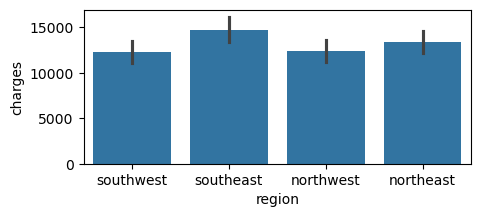

In [8]:
# region
plt.figure(figsize=(5,2))
sns.barplot(data,x="region",y="charges")
plt.show()

In [9]:
data.loc[:,"Region"]=data.loc[:,'region'].map({'southwest':0,'northwest':1,'northeast':2,'southeast':3})

In [10]:
data.drop(columns='region',inplace=True)

# Scalling
### Scaling If there is a huge variation among the values in different numerical column we using scaling to bring all the values to a same scale so that calculations becomes easy.
## Minmax scaler
## Standard scaler

# Minmax scaler
#Minmax scaler It transforms all the values into a range of 0 to 1.
### x_scaled=x - x_min/  x_max-x_min

In [12]:
df=data.copy()

In [14]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
data[['age']]=scaler.fit_transform(data[['age']])
data[['bmi']]=scaler.fit_transform(data[['bmi']])

# Standard Scaler
### It transforms all the values to same scale so that mean of column of column will be 0 and std will be 1.
### z= x-Mue/sigma

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['age']]=scaler.fit_transform(df[['age']])
df[['bmi']]=scaler.fit_transform(df[['bmi']])

# Log Transformation
### Usually applied on target column only in regression.
### It is used to transform skewed data into normal distribution.
### Linear regression expects data distribution of target to be normal.

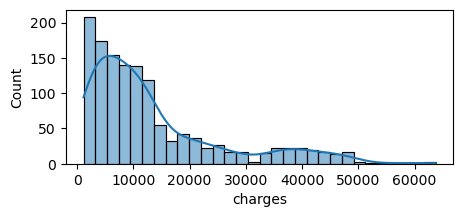

In [16]:
# charges
plt.figure(figsize=(5,2))
sns.histplot(data,x='charges',kde=True)
plt.show()

In [17]:
data.loc[:,'charges']= np.log(data.loc[:,'charges'])

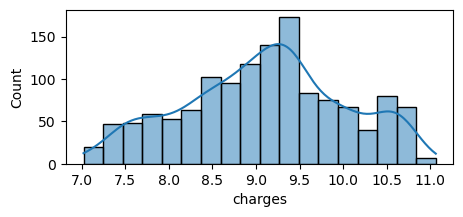

In [18]:
plt.figure(figsize=(5,2))
sns.histplot(data,x='charges',kde=True)
plt.show()